In [10]:
# Tell Jupyter to display plots directly in the notebook
%matplotlib inline
import os
import sys
import pandas as pd
import numpy as np

# Import your custom functions from your modeling script!
# (If your file is named model.py instead of modeling.py, change the import below)
%load_ext autoreload
%autoreload 2
sys.path.append(os.path.abspath("../"))

from src.modeling import split_data, train_models, evaluate_model, plot_metrics, evaluate_classifier


# Load your data
# df = pd.read_csv('your_data.csv')
project_root = os.path.abspath('../')
txt_path = os.path.join(project_root, 'data', 'preprocessed_data.csv')

print("1. Loading and Splitting Data...")
df = pd.read_csv(txt_path)

target_col = 'TotalClaims'
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2)

# Clean columns for XGBoost
X_train.columns = X_train.columns.str.replace(r'[\[\]<]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<]', '', regex=True)





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
1. Loading and Splitting Data...


In [2]:
print("2. Training Models (This may take a moment)...")
lr, dt, rfr, xgb_mod = train_models(X_train, y_train)

2. Training Models (This may take a moment)...
2026-05-28 10:09:33,354 - INFO - Training Linear Regression...
2026-05-28 10:09:42,719 - INFO - Training Decision Tree...
2026-05-28 10:10:05,869 - INFO - Training Random Forest (This may take a moment)...
2026-05-28 10:14:26,391 - INFO - Training XGBoost...
2026-05-28 10:14:36,130 - INFO - All models trained successfully.


In [3]:
print("3. Evaluating Models...")
mae_lr, mse_lr, r2_lr, _ = evaluate_model(lr, X_test, y_test)
mae_dt, mse_dt, r2_dt, _ = evaluate_model(dt, X_test, y_test)
mae_rfr, mse_rfr, r2_rfr, _ = evaluate_model(rfr, X_test, y_test)
mae_xgb, mse_xgb, r2_xgb, _ = evaluate_model(xgb_mod, X_test, y_test)



3. Evaluating Models...


In [9]:
models_list = ['Linear Reg', 'Decision Tree', 'Random Forest', 'XGBoost']
r2_scores = [r2_lr, r2_dt, r2_rfr, r2_xgb]
mse_scores = [mse_lr, mse_dt, mse_rfr, mse_xgb]

# Print a formatted table
print(f"\n{'Model':<20} | {'RMSE':<15} | {'R-Squared (R²)'}")
print("-" * 55)
for i in range(len(models_list)):
    rmse = np.sqrt(mse_scores[i])
    print(f"{models_list[i]:<20} | ${rmse:<14,.2f} | {r2_scores[i]:.4f}\n")


Model                | RMSE            | R-Squared (R²)
-------------------------------------------------------
Linear Reg           | $2,277.86       | 0.0090

Decision Tree        | $2,735.15       | -0.4289

Random Forest        | $2,639.62       | -0.3308

XGBoost              | $2,475.00       | -0.1700



In [4]:
models_list = ['Linear Reg', 'Decision Tree', 'Random Forest', 'XGBoost']
r2_scores = [r2_lr, r2_dt, r2_rfr, r2_xgb]
mae_scores = [mae_lr, mae_dt, mae_rfr, mae_xgb]
mse_scores = [mse_lr, mse_dt, mse_rfr, mse_xgb]



4. Generating Plots...
2026-05-28 10:14:39,823 - INFO - Generating performance visualizations...


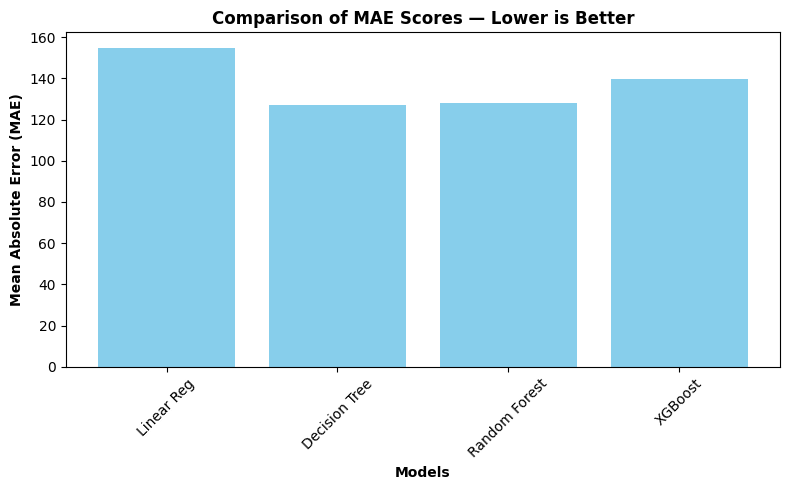

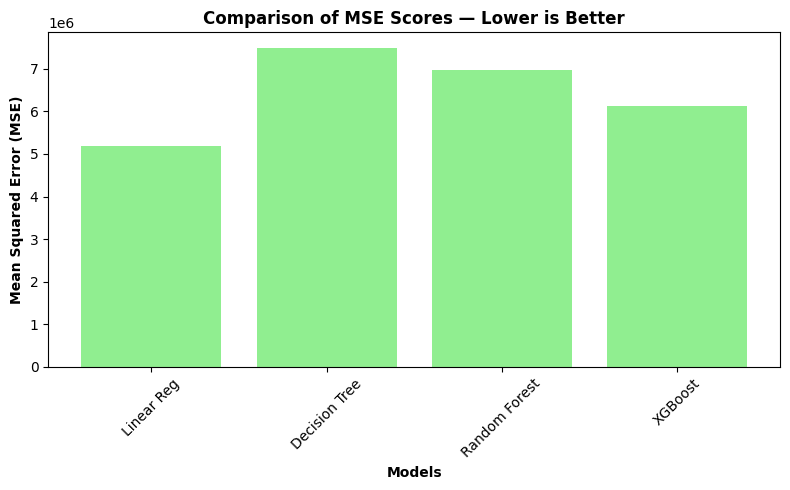

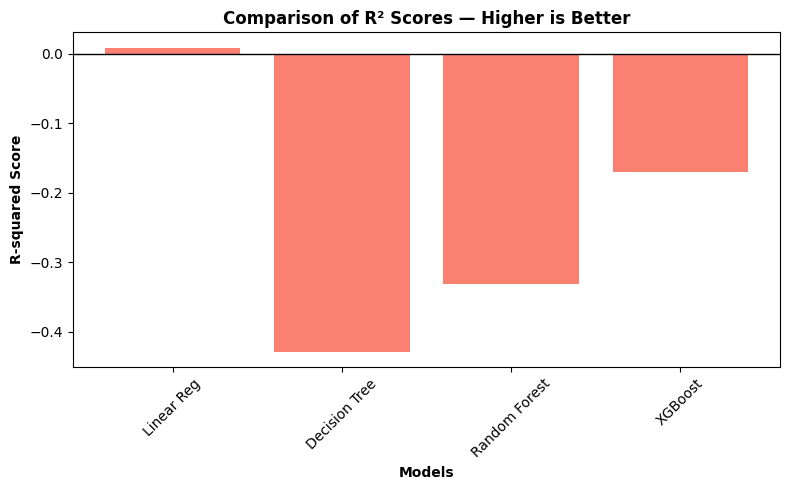

In [6]:
print("4. Generating Plots...")
plot_metrics(models_list, mae_scores, mse_scores, r2_scores)

The R² chart reveals a critical reality: Linear Regression is the only model that manages to beat a simple average guess (barely, with an R² sitting right at 0). Our advanced models—Decision Tree, Random Forest, and XGBoost—all produced negative R² scores and wildly high MSE scores, meaning they perform worse than simply guessing the mean claim amount. However, paradoxically, the MAE chart shows these same tree-based models actually performed better than Linear Regression on absolute error.

Why this happens: This contradiction occurs because insurance claim data contains extreme, heavy-tailed outliers (a few massive, multi-million dollar crashes). MAE treats all errors equally, so our tree models score well on MAE because they successfully predict the vast majority of small, standard claims. However, MSE squares the errors. Because the tree models completely fail to predict the massive, extreme outlier claims, those massive errors get squared, which completely destroys their MSE and R² scores.

Business Recommendation: We cannot deploy these raw regression models into production to predict exact claim severity. Standard algorithms struggle with heavy-tailed financial distributions. To accurately price risk moving forward, the data science team must switch to Generalized Linear Models (GLMs) using a Tweedie or Gamma distribution, which are mathematically designed specifically to handle extreme insurance outliers.

c:\Users\Hermela\Desktop\10academy\week3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data and model...
Calculating SHAP values...


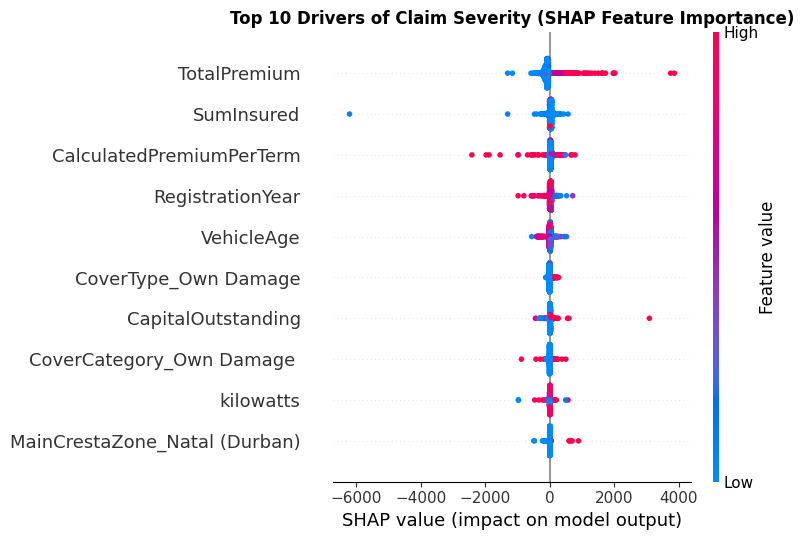

In [8]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("Loading data and model...")
# Load the preprocessed data and recreate the test set
df = pd.read_csv('../data/preprocessed_data.csv') 
X = df.drop(columns=['TotalClaims'])
y = df['TotalClaims']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Load the trained XGBoost model that your script just saved
xgb_model = joblib.load('../models/xgboost.joblib')

print("Calculating SHAP values...")
# Sample 1000 rows to make the computation fast so it doesn't freeze your computer
X_test_sample = shap.sample(X_test, 1000) 
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

# Plot the top 10 most influential features
plt.figure(figsize=(10, 6))
plt.title("Top 10 Drivers of Claim Severity (SHAP Feature Importance)", fontweight='bold')
shap.summary_plot(shap_values, X_test_sample, max_display=10)

The SHAP summary plot reveals that purely financial policy metrics are the absolute strongest drivers of claim severity. TotalPremium and SumInsured are our top two predictors; high values in these categories (the red dots extending far to the right) violently push the predicted claim severity upward.

Beyond baseline financials, specific policy configurations and vehicle details matter:

Coverage Type: Policies containing Own Damage coverage consistently predict higher claim payouts.

Vehicle Age: Higher VehicleAge (red dots) generally pulls the predicted claim amount down (negative SHAP value), meaning older cars result in cheaper claims, likely because their maximum total-loss value is heavily depreciated.

Location: Policies originating in MainCrestaZone_Natal (Durban) show a distinct trend of pushing predicted severity higher.

Business Recommendation: We must hardcode these specific feature weights into our underwriting rules. Because the model definitively proves that high TotalPremium/SumInsured limits and Own Damage coverage drive extreme claim severity, pricing actuaries must secure adequate reinsurance for these specific high-tier policies. Furthermore, we should confidently offer targeted premium discounts for older vehicles, as the algorithm confirms they represent a strictly lower financial liability.